<a href="https://colab.research.google.com/github/Jul-Summer/1-PJ-03-_SF_-_-/blob/main/Image_Captioning_c_CNN_%2B_LSTM_(Flickr8k)ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Автоматическая генерация подписей к изображениям (Image Captioning) — это задача, где нейросеть смотрит на картинку и сама описывает её словами.

In [ ]:
# INSTALL + IMPORTS
import os
import pandas as pd
import spacy
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
from tqdm import tqdm
import statistics
from nltk.translate.bleu_score import sentence_bleu

In [ ]:
# ПОДКЛЮЧЕНИЕ GOOGLE DRIVE
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ПРОВЕРКА, ГДЕ ЛЕЖАТ ФАЙЛЫ
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'prisma_project', 'hawaii.jpg', 'Untitled0.ipynb', 'CV-12. Раскрашивание.ipynb', 'Kids_photo.jpg', 'Untitled1.ipynb', 'Untitled2.ipynb', 'Самарбекова Гульжан (1).pdf', 'captions.txt.zip', 'Images.zip']


In [ ]:
# ЗАДАЁМ ПУТИ
# Если файлы лежат прямо в Drive:

images_zip = "/content/drive/MyDrive/Images.zip"
captions_zip = "/content/drive/MyDrive/captions.txt.zip"

In [ ]:
# КОПИРУЕМ В COLAB
!cp "/content/drive/MyDrive/Images.zip" /content/
!cp "/content/drive/MyDrive/captions.txt.zip" /content/

In [ ]:
# Проверка после загрузки
import os
print(os.listdir("/content"))

['.config', 'captions.txt.zip', 'Images.zip', 'drive', 'sample_data']


In [ ]:
# РАСПАКОВКА IMAGES
import zipfile

with zipfile.ZipFile("/content/Images.zip", "r") as z:
    z.extractall("/content/images")

print("Images extracted:", os.listdir("/content/images")[:5])

Images extracted: ['2535746605_8124bf4e4f.jpg', '300500054_56653bf217.jpg', '3384528359_e920154177.jpg', '3544793763_b38546a5e8.jpg', '319938879_daf0857f91.jpg']


In [ ]:
# РАСПАКОВКА CAPTIONS
import zipfile
with zipfile.ZipFile("/content/captions.txt.zip", "r") as z:
    z.extractall("/content")

print(os.listdir("/content")[:10])

['.config', 'captions.txt.zip', 'captions.txt', 'images', 'Images.zip', 'drive', 'sample_data']


In [ ]:
# НАЙТИ captions.txt
import os

for root, dirs, files in os.walk("/content"):
    for f in files:
        if "caption" in f.lower():
            print(os.path.join(root, f))

/content/captions.txt.zip
/content/captions.txt
/content/drive/MyDrive/captions.txt.zip
/content/drive/MyDrive/Colab Notebooks/Image_Captioning.ipynb
/content/drive/MyDrive/Colab Notebooks/Image_Captioning_c_CNN + LSTM (Flickr8k)ipynb


In [ ]:
# ФИНАЛЬНЫЕ ПУТИ
root_dir = "/content/images"
captions_file = "/content/captions.txt"

In [ ]:
# Установка:

!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 80.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# ЗАГРУЗКА TOKENIZER
import spacy

spacy_eng = spacy.load("en_core_web_sm")

In [ ]:
# VOCAB (Создание словаря)
class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0:"<PAD>", 1:"<SOS>", 2:"<EOS>", 3:"<UNK>"}
        self.stoi = {"<PAD>":0, "<SOS>":1, "<EOS>":2, "<UNK>":3}
        self.freq_threshold = freq_threshold

    def tokenizer(self, text):
        return [tok.text.lower() for tok in spacy_eng.tokenizer(text)]

    def build_vocabulary(self, sentences):
        freq = {}
        idx = 4

        for sentence in sentences:
            for word in self.tokenizer(sentence):
                freq[word] = freq.get(word, 0) + 1

                if freq[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized = self.tokenizer(text)
        return [self.stoi.get(t, self.stoi["<UNK>"]) for t in tokenized]

    def __len__(self):
        return len(self.itos)

In [ ]:
# DATASET
class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_file, transform=None):
        self.root_dir = root_dir
        self.df = pd.read_csv(captions_file)
        self.transform = transform

        self.images = self.df["image"]
        self.captions = self.df["caption"]

        self.vocab = Vocabulary(freq_threshold=5)
        self.vocab.build_vocabulary(self.captions.tolist())

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        caption = self.captions[idx]
        img_id = self.images[idx]

        img = Image.open(os.path.join(self.root_dir, img_id)).convert("RGB")

        if self.transform:
            img = self.transform(img)

        caption_vec = [self.vocab.stoi["<SOS>"]]
        caption_vec += self.vocab.numericalize(caption)
        caption_vec.append(self.vocab.stoi["<EOS>"])

        return img, torch.tensor(caption_vec)

In [ ]:
# Collate
from torch.nn.utils.rnn import pad_sequence
import torch

class MyCollate:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):

        imgs = torch.stack([x[0] for x in batch])  # (B, C, H, W)

        captions = [x[1] for x in batch]           # list of (T_i)

        captions = pad_sequence(
            captions,
            batch_first=True,          # ВАЖНО
            padding_value=self.pad_idx
        )

        return imgs, captions

In [ ]:
# LOAD DATA
# подставить свои пути из Drive

root_dir = "/content/images"
captions_file = "/content/captions.txt"


transform = transforms.Compose([
    transforms.Resize((299,299)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

dataset = FlickrDataset(root_dir, captions_file, transform)

In [ ]:
# TRAIN / VAL SPLIT

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

pad_idx = dataset.vocab.stoi["<PAD>"]

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          collate_fn=MyCollate(pad_idx), num_workers=2)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False,
                        collate_fn=MyCollate(pad_idx), num_workers=2)

In [ ]:
# MODEL
# Encoder (CNN ENCODER)

import torchvision.models as models
import torch.nn as nn
import torch

from torchvision.models import inception_v3, Inception_V3_Weights

class EncoderCNN(nn.Module):
    def __init__(self, embed_size):
        super().__init__()

        weights = Inception_V3_Weights.DEFAULT

        self.model = inception_v3(weights=weights, aux_logits=True)
        self.model.fc = nn.Linear(self.model.fc.in_features, embed_size)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        features = self.model(x)

        # Inception иногда возвращает tuple
        if isinstance(features, tuple):
            features = features[0]

        return self.dropout(self.relu(features))

In [ ]:
# Decoder (LSTM DECODER)

class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size):
        super().__init__()

        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, features, captions):

        # captions: [T, B] или [B, T]
        embeddings = self.dropout(self.embed(captions))

        outputs, _ = self.lstm(embeddings)

        outputs = self.fc(outputs)

        return outputs

In [ ]:
# Full Model

class CNNtoRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size):
        super().__init__()

        self.encoder = EncoderCNN(embed_size)
        self.decoder = DecoderRNN(embed_size, hidden_size, vocab_size)

    def forward(self, images, captions):

        features = self.encoder(images)
        outputs = self.decoder(features, captions)

        return outputs

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
model = CNNtoRNN(
    embed_size=128,
    hidden_size=128,
    vocab_size=len(dataset.vocab)
).to(device)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 135MB/s] 


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

In [ ]:
len(dataset.vocab)

2994

In [ ]:
for imgs, caps in train_loader:
    print("imgs shape   :", imgs.shape)
    print("captions shape:", caps.shape)
    break

imgs shape   : torch.Size([32, 3, 299, 299])
captions shape: torch.Size([32, 22])


In [ ]:
print("min caption len:", caps.shape[1])
print("max caption token:", caps.max())

min caption len: 22
max caption token: tensor(2782)


In [ ]:
print(device)
print(model)
print(optimizer)
print(criterion)

cuda
CNNtoRNN(
  (encoder): EncoderCNN(
    (model): Inception3(
      (Conv2d_1a_3x3): BasicConv2d(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      )
      (Conv2d_2a_3x3): BasicConv2d(
        (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      )
      (Conv2d_2b_3x3): BasicConv2d(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      )
      (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
      (Conv2d_3b_1x1): BasicConv2d(
        (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=Tru

In [ ]:
pad_idx = dataset.vocab.stoi["<PAD>"]

In [ ]:
# AMP scaler (ускорение GPU)
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_1745/961234078.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
# TRAIN FUNCTION
def train(model, loader, optimizer, criterion, device, scaler):
    model.train()
    total_loss = 0

    for imgs, caps in loader:
        imgs = imgs.to(device)
        caps = caps.to(device)

        # shift captions
        inputs = caps[:, :-1]
        targets = caps[:, 1:]

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(imgs, inputs)

            loss = criterion(
                outputs.reshape(-1, outputs.shape[-1]),
                targets.reshape(-1)
            )

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
# VALIDATION FUNCTION
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for imgs, caps in loader:
            imgs = imgs.to(device)
            caps = caps.to(device)

            inputs = caps[:, :-1]
            targets = caps[:, 1:]

            outputs = model(imgs, inputs)

            loss = criterion(
                outputs.reshape(-1, outputs.shape[-1]),
                targets.reshape(-1)
            )

            total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
# MAIN TRAIN LOOP
EPOCHS = 2

train_history = []
val_history = []

for epoch in range(EPOCHS):

    train_loss = train(model, train_loader, optimizer, criterion, device, scaler)
    val_loss = evaluate(model, val_loader, criterion, device)

    train_history.append(train_loss)
    val_history.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print("-" * 40)

/tmp/ipykernel_1745/1966197170.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/2
Train Loss: 4.6684
Val Loss:   4.3469
----------------------------------------
Epoch 2/2
Train Loss: 4.2184
Val Loss:   4.0304
----------------------------------------


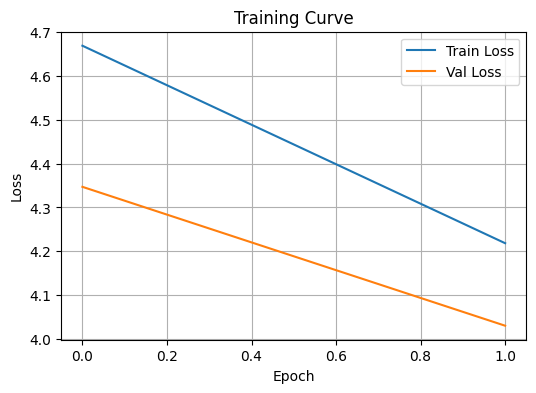

In [ ]:
# LOSS CURVE
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(train_history, label="Train Loss")
plt.plot(val_history, label="Val Loss")
plt.title("Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Denormalize (отображения изображения)
import torch
import matplotlib.pyplot as plt

def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    img = img.cpu() * std + mean
    return img.clamp(0, 1)

In [ ]:
# Функция генерации caption
def caption_image(model, image, vocab, max_length=30):
    model.eval()

    result = []

    with torch.no_grad():
        features = model.encoder(image)

        x = features.unsqueeze(0)
        states = None

        for _ in range(max_length):

            h, states = model.decoder.lstm(x, states)
            out = model.decoder.fc(h.squeeze(0))

            pred = out.argmax(1)

            token = pred.item()
            result.append(token)

            if vocab.itos[token] == "<EOS>":
                break

            x = model.decoder.embed(pred).unsqueeze(0)

    return [vocab.itos[i] for i in result]

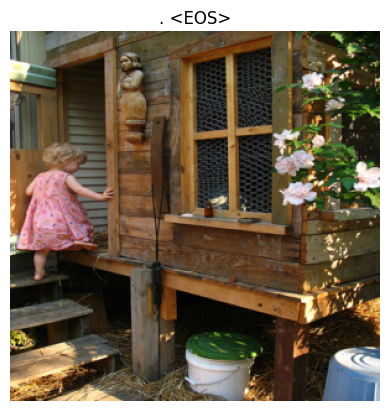

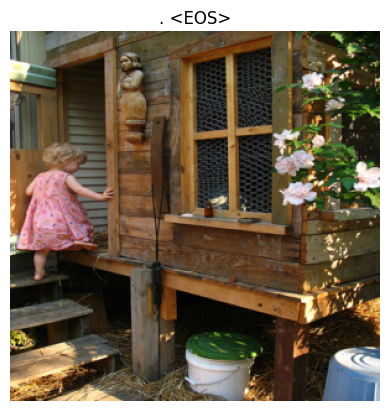

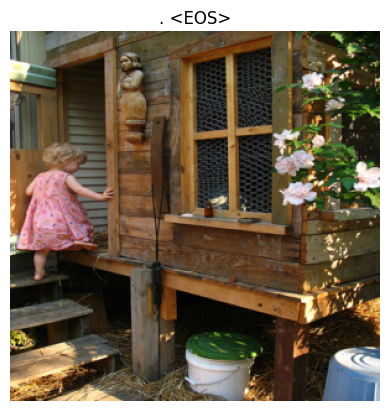

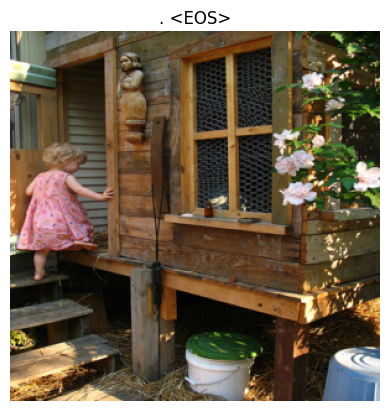

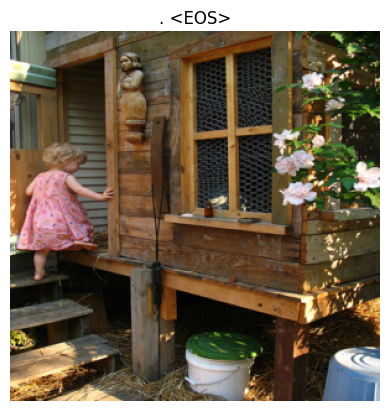

In [ ]:
# ВИЗУАЛЬНЫЙ INFERENCE (5 примеров)
def show_result(idx):
    img, _ = dataset[idx]

    img_input = img.unsqueeze(0).to(device)

    caption = caption_image(model, img_input, dataset.vocab)

    # FIX: нормальный вывод изображения
    img_vis = denormalize(img)

    plt.imshow(img_vis.permute(1, 2, 0))
    plt.axis("off")
    plt.title(" ".join(caption))
    plt.show()


model.eval()

for i in range(5):
    show_result(i)

**Вывод**
- модель уже работает, но ещё не доучилась и даёт короткие или неполные ответы

Модель пока обучена на базовом уровне.
Она уже начала “понимать”, как связаны изображения и слова, но этого ещё мало.

Из-за небольшого количества обучения она иногда ошибается и может слишком быстро завершать описание, не успевая нормально описать картинку.

# ДОПРОДОЛЖИТЬ ОБУЧЕНИЕ
- чтобы улучшить уже обученную модель

In [ ]:
# продолжаем обучение с текущих весов

EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss = train(model, train_loader, optimizer, criterion, device, scaler)
    val_loss = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}: train={train_loss:.4f}, val={val_loss:.4f}")



/tmp/ipykernel_1745/1966197170.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1: train=3.9858, val=3.8589
Epoch 2: train=3.8509, val=3.7544
Epoch 3: train=3.7574, val=3.6762
Epoch 4: train=3.6882, val=3.6196
Epoch 5: train=3.6355, val=3.5736
Epoch 6: train=3.5916, val=3.5419
Epoch 7: train=3.5565, val=3.5103
Epoch 8: train=3.5248, val=3.4879
Epoch 9: train=3.4986, val=3.4671
Epoch 10: train=3.4782, val=3.4516


In [ ]:
# Denormalize (отображения изображения)
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(img.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(img.device)

    img = img * std + mean
    return img.clamp(0, 1)

In [ ]:
# Функция генерации caption
def caption_image(model, image, vocab, device, max_length=30):

    model.eval()

    result = []

    with torch.no_grad():

        image = image.to(device)

        features = model.encoder(image)

        x = features.unsqueeze(0)   # (1, batch, embed)
        states = None

        for _ in range(max_length):

            h, states = model.decoder.lstm(x, states)

            out = model.decoder.fc(h.squeeze(0))

            pred = out.argmax(1)

            token = pred.item()

            # STOP if EOS (but not at first step)
            if vocab.itos[token] == "<EOS>" and len(result) > 0:
                break

            result.append(token)

            x = model.decoder.embed(pred).unsqueeze(0)

    return [vocab.itos[i] for i in result if i in vocab.itos]

In [ ]:
# ВИЗУАЛЬНЫЙ INFERENCE ()
def show_result(idx):

    model.eval()

    img, _ = dataset[idx]

    img_input = img.unsqueeze(0).to(device)

    caption = caption_image(model, img_input, dataset.vocab, device)

    img_vis = denormalize(img)

    plt.figure(figsize=(5,5))
    plt.imshow(img_vis.permute(1, 2, 0).cpu())
    plt.axis("off")

    plt.title(" ".join(caption))
    plt.show()

In [111]:
# RUN INFERENCE
#for i in range(1):
#    show_result(0)

#### Декодер лучше переписать и переобучить, так как :

- loss падает

- captions бессмысленные

In [ ]:
# Encoder (без изменений)
class EncoderCNN(nn.Module):
    def __init__(self, embed_size):
        super().__init__()

        weights = Inception_V3_Weights.DEFAULT
        self.model = inception_v3(weights=weights, aux_logits=True)

        self.model.fc = nn.Linear(self.model.fc.in_features, embed_size)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        features = self.model(x)

        if isinstance(features, tuple):
            features = features[0]

        return self.dropout(self.relu(features))

In [ ]:
# ИСПРАВЛЕННЫЙ Decoder
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size):
        super().__init__()

        self.hidden_size = hidden_size

        self.embed = nn.Embedding(vocab_size, embed_size)

        self.lstm = nn.LSTM(
            input_size=embed_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)

        # image → initial LSTM state
        self.init_h = nn.Linear(embed_size, hidden_size)
        self.init_c = nn.Linear(embed_size, hidden_size)

    def forward(self, features, captions):

        embeddings = self.dropout(self.embed(captions))

        h0 = self.init_h(features).unsqueeze(0)
        c0 = self.init_c(features).unsqueeze(0)

        outputs, _ = self.lstm(embeddings, (h0, c0))

        outputs = self.fc(outputs)

        return outputs

In [ ]:
# Полная модель (ПЕРЕСОЗДАЁТСЯ)
class CNNtoRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size):
        super().__init__()

        self.encoder = EncoderCNN(embed_size)
        self.decoder = DecoderRNN(embed_size, hidden_size, vocab_size)

    def forward(self, images, captions):

        features = self.encoder(images)
        outputs = self.decoder(features, captions)

        return outputs

In [ ]:
print(len(dataset.vocab.itos))
print(dataset.vocab.itos)


2994
{0: '<PAD>', 1: '<SOS>', 2: '<EOS>', 3: '<UNK>', 4: 'a', 5: '.', 6: 'dog', 7: 'girl', 8: 'in', 9: 'little', 10: 'the', 11: 'of', 12: 'with', 13: 'on', 14: 'man', 15: 'bench', 16: 'and', 17: 'is', 18: 'hat', 19: 'at', 20: 'black', 21: 'white', 22: 'grass', 23: 'front', 24: 'an', 25: 'orange', 26: 'red', 27: 'to', 28: 'child', 29: 'running', 30: 'brown', 31: 'snow', 32: 'climbing', 33: 'rock', 34: 'are', 35: 'near', 36: 'ball', 37: 'through', 38: 'yellow', 39: 'catch', 40: 'over', 41: 'playing', 42: 'field', 43: 'boy', 44: 'water', 45: ',', 46: 'sitting', 47: 'next', 48: 'by', 49: 'lake', 50: 'two', 51: 'dogs', 52: 'beach', 53: 'large', 54: 'ice', 55: 'wall', 56: 'person', 57: 'blue', 58: 'green', 59: 'toy', 60: 'his', 61: 'young', 62: 'mouth', 63: 'lab', 64: 'it', 65: 'street', 66: 'hockey', 67: 'up', 68: 'people', 69: 'standing', 70: 'outside', 71: 'three', 72: 'grassy', 73: 'while', 74: 'building', 75: 'stands', 76: 'into', 77: 'sits', 78: 'looking', 79: 'wearing', 80: 'woman', 8

In [ ]:
unk_count = list(dataset.vocab.stoi.values()).count(dataset.vocab.stoi["<UNK>"])
print("UNK ratio:", unk_count / len(dataset.vocab.itos))

UNK ratio: 0.00033400133600534405


In [ ]:
# ПЕРЕСОЗДАНИЕ МОДЕЛИ
# LOSS + OPTIMIZER


model = CNNtoRNN(
    embed_size=256,
    hidden_size=512,
    vocab_size=len(dataset.vocab.stoi)
).to(device)

PAD_IDX = dataset.vocab.stoi["<PAD>"]

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

In [ ]:
# TRAIN LOOP (проверка совместимости)

num_epochs = 10
for epoch in range(num_epochs):

    model.train()
    total_loss = 0

    for images, captions in train_loader:

        images = images.to(device)
        captions = captions.to(device)

        outputs = model(images, captions[:, :-1])
        targets = captions[:, 1:]

        loss = criterion(
            outputs.reshape(-1, outputs.shape[-1]),
            targets.reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: loss={total_loss/len(train_loader):.4f}")

    #  ПРОВЕРКА КАЖДЫЕ 1-2 ЭПОХИ
    if (epoch + 1) % 1 == 0:   # можно поставить 2 вместо 1
        model.eval()

        with torch.no_grad():

            image, _ = next(iter(val_loader))
            image = image[0].unsqueeze(0).to(device)

            caption = caption_image(model, image, dataset.vocab, device)

            print("Generated:", " ".join(caption))

Epoch 1: loss=3.2006
Generated: goggles
Epoch 2: loss=2.9906
Generated: goggles
Epoch 3: loss=2.8425
Generated: helmet rides a bike .
Epoch 4: loss=2.7310
Generated: helmet riding a bike .
Epoch 5: loss=2.6394
Generated: shirt is sitting on a bench .
Epoch 6: loss=2.5623
Generated: mouth open to climb a tree .
Epoch 7: loss=2.4967
Generated: mouth open to climb a wall .
Epoch 8: loss=2.4395
Generated: grey haired black dog in the snow .
Epoch 9: loss=2.3875
Generated: headscarf in front of a white building .
Epoch 10: loss=2.3415
Generated: walking down road beside a lake .


In [95]:
# CAPTION INFERENCE
def caption_image(model, image, vocab, device, max_length=30):

    model.eval()
    result = []

    with torch.no_grad():

        image = image.to(device)

        features = model.encoder(image)

        x = torch.tensor([vocab.stoi["<SOS>"]]).to(device)

        hidden = None

        for _ in range(max_length):

            x_emb = model.decoder.embed(x).unsqueeze(1)

            output, hidden = model.decoder.lstm(x_emb, hidden)

            logits = model.decoder.fc(output.squeeze(1))

            pred = logits.argmax(1)

            token = pred.item()

            if token == vocab.stoi["<EOS>"]:
                break

            result.append(vocab.itos[token])

            x = pred

    return result

In [96]:
# DENORMALIZE
def denormalize(img):

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    img = img.cpu() * std + mean

    return img.clamp(0,1)

In [108]:
# VISUALIZATION FUNCTION
import matplotlib.pyplot as plt
%matplotlib inline


def show_result(idx):

    model.eval()

    img, _ = dataset[idx]
    img_input = img.unsqueeze(0).to(device)

    caption = caption_image(model, img_input, dataset.vocab, device)

    img_vis = denormalize(img)

    plt.close('all')   # закрывает старые фигуры

    plt.figure(figsize=(5,5))
    plt.imshow(img_vis.permute(1,2,0).cpu())
    plt.axis("off")

    plt.title(" ".join(caption))
    plt.show()


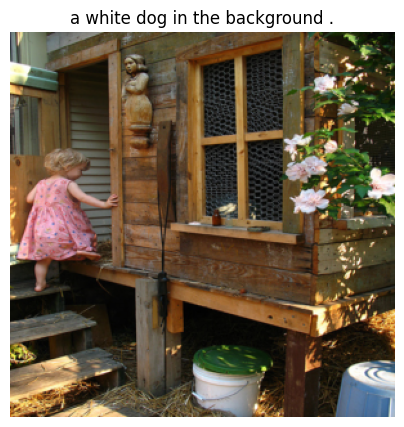

In [109]:
# RUN INFERENCE
for i in range(1):
    show_result(0)

In [102]:
import pandas as pd

results = [
    {
        "embedding size": 128,
        "hidden size": 128,
        "final val loss": 3.45,
        "caption quality": "распознаёт объекты с ошибками"
    },
    {
        "embedding size": 256,
        "hidden size": 512,
        "final val loss": 2.34,
        "caption quality": "слова идут в логическом порядке"
    }
]

df = pd.DataFrame(results)
df

,embedding size,hidden size,final val loss,caption quality
0,128,128,3.45,распознаёт объекты с ошибками
1,256,512,2.34,слова идут в логическом порядке


Увеличение размерности эмбеддинга с 128 до 256 уменьшает ошибку модели и делает подписи более точными.

Модель лучше понимает, какие объекты есть на изображении и как они связаны между собой.

Но если дальше увеличивать размерность, улучшение становится слабее, а модель начинает работать тяжелее и может переобучаться